# NCA vegetation FCM — coarse K=5, m=1.33

This is a focused refit of the vegetation parent space at **K = 5** and **m = 1.33**.

It intentionally preserves the final vegetation-clustering workflow:

- input: `C:\NCA_DATA\Vegetation Data\NCA_Master_Aligned_spp_fg_through2026.csv`
- 10 functional-group variables
- row closure to proportional composition
- Hellinger transformation
- fuzzy c-means
- 20 starts
- random seeds beginning at 42
- `max_iter = 300`
- `tol = 1e-5`
- membership/core threshold = 0.60

This notebook does **not** redo species-level subclustering. Its purpose is to produce the independently fit coarse K=5 vegetation labels and then compare them directly with the retained K=8 parent solution.

K=5 cluster numbers are local labels. They should not be interpreted as equivalent to the existing P1–P8 numbering until the K5↔K8 crosswalk is inspected.

In [1]:
# =============================================================================
# 0. IMPORTS / PATHS / FIXED SETTINGS
# =============================================================================

from __future__ import annotations

import os
os.environ.setdefault("OMP_NUM_THREADS", "1")

from pathlib import Path
from itertools import combinations
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist, pdist

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
)

pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 240)

COMBINED_PATH = Path(
    r"C:\NCA_DATA\Vegetation Data\NCA_Master_Aligned_spp_fg_through2026.csv"
)

K8_ASSIGNMENTS_PATH = Path(
    r"C:\NCA_DATA\Vegetation Data\Clustering_Veg\Derived"
    r"\NCA_FCM_K8_m1p33_parent_assignments.csv"
)

OUTPUT_DIR = (
    COMBINED_PATH.parent
    / "Clustering_Veg"
    / "K5_m1p33"
)

DERIVED_DIR = OUTPUT_DIR / "Derived"
TABLE_DIR = OUTPUT_DIR / "Tables"
FIG_DIR = OUTPUT_DIR / "Figures"

for d in [OUTPUT_DIR, DERIVED_DIR, TABLE_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

K = 5
M = 1.33
N_STARTS = 20
RANDOM_STATE = 42
MAX_ITER = 300
TOL = 1e-5
CORE_MEMBERSHIP = 0.60

FG_ALL = [
    "ARTR_FG",
    "SHRUB_FG",
    "PBG_FG",
    "EAG_FG",
    "EF_FG",
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "LITTER_FG",
    "OTHER_FG",
    "NPF_FG",
]

FG_LABELS = {
    "ARTR_FG": "ARTR",
    "SHRUB_FG": "Shrub",
    "PBG_FG": "PBG",
    "EAG_FG": "EAG",
    "EF_FG": "EF",
    "BAREGROUND_FG": "Bare",
    "BIOCRUST_FG": "Biocrust",
    "LITTER_FG": "Litter",
    "OTHER_FG": "Other",
    "NPF_FG": "NPF",
}

print("Input:", COMBINED_PATH)
print("Existing K=8:", K8_ASSIGNMENTS_PATH)
print("Output:", OUTPUT_DIR)
print(f"K={K}, m={M:.2f}, starts={N_STARTS}")

Input: C:\NCA_DATA\Vegetation Data\NCA_Master_Aligned_spp_fg_through2026.csv
Existing K=8: C:\NCA_DATA\Vegetation Data\Clustering_Veg\Derived\NCA_FCM_K8_m1p33_parent_assignments.csv
Output: C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33
K=5, m=1.33, starts=20


## 1. Load the finalized vegetation master and reproduce the parent feature space

As before, parent clustering uses the ten functional-group columns only. Raw cover is row-closed and then Hellinger transformed:

\[
p_{ij}=\frac{x_{ij}}{\sum_j x_{ij}},
\qquad
h_{ij}=\sqrt{p_{ij}}.
\]

In [2]:
# =============================================================================
# 1. LOAD / VALIDATE / HELLINGER
# =============================================================================

if not COMBINED_PATH.exists():
    raise FileNotFoundError(COMBINED_PATH)

master = pd.read_csv(COMBINED_PATH, low_memory=False)
master = master.drop(
    columns=[c for c in master.columns if c.startswith("Unnamed:")],
    errors="ignore",
)

missing_fg = [c for c in FG_ALL if c not in master.columns]
if missing_fg:
    raise ValueError(
        f"Combined master is missing parent FG columns: {missing_fg}"
    )

fg_raw = (
    master[FG_ALL]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
)

row_sum = fg_raw.sum(axis=1).to_numpy()
keep_parent = row_sum > 0

if not np.all(keep_parent):
    warnings.warn(
        f"{np.sum(~keep_parent)} rows have zero total FG cover and cannot enter parent FCM."
    )

master_parent = master.loc[keep_parent].copy().reset_index(drop=True)
fg_raw = fg_raw.loc[keep_parent].reset_index(drop=True)

X_prop = (
    fg_raw.to_numpy(dtype=np.float64)
    / fg_raw.sum(axis=1).to_numpy()[:, None]
)
X = np.sqrt(X_prop)

print(f"Rows in combined master: {len(master):,}")
print(f"Rows entering FCM:       {len(master_parent):,}")
print(f"FG dimensions:           {X.shape[1]}")
print(f"Hellinger matrix:         {X.shape}")

print("\nRaw FG row-sum summary:")
display(
    fg_raw.sum(axis=1)
    .describe()
    .to_frame("FG row sum")
    .T
)

if len(master) != 1171:
    warnings.warn(
        "The retained final workflow had 1,171 rows. "
        f"Current file contains {len(master):,}."
    )

Rows in combined master: 1,171
Rows entering FCM:       1,171
FG dimensions:           10
Hellinger matrix:         (1171, 10)

Raw FG row-sum summary:


,count,mean,std,min,25%,50%,75%,max
FG row sum,1171.0,99.98883,0.110597,97.95,100.0,100.0,100.0,102.483333


## 2. Fuzzy c-means helpers

This is the same FCM formulation used in the retained vegetation workflow. The best of 20 starts is selected by minimum FCM objective.

Restart ARI is added here only as a reproducibility diagnostic; it does not participate in model selection.

In [3]:
# =============================================================================
# 2. FCM HELPERS
# =============================================================================

def init_membership(n: int, k: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    U = rng.random((n, k))
    return U / U.sum(axis=1, keepdims=True)


def fuzzy_cmeans(
    X: np.ndarray,
    k: int,
    m: float,
    *,
    max_iter: int = 300,
    tol: float = 1e-5,
    seed: int = 42,
):
    if m <= 1:
        raise ValueError("FCM requires m > 1.")

    n = X.shape[0]
    eps = 1e-12
    U = init_membership(n, k, seed)
    converged = False

    for iteration in range(1, max_iter + 1):
        U_old = U.copy()

        Um = U ** m
        centers = (Um.T @ X) / (Um.sum(axis=0)[:, None] + eps)

        D = np.maximum(
            cdist(X, centers, metric="euclidean"),
            eps,
        )

        power = -2.0 / (m - 1.0)
        W = D ** power
        U = W / W.sum(axis=1, keepdims=True)

        if np.max(np.abs(U - U_old)) < tol:
            converged = True
            break

    Um = U ** m
    centers = (Um.T @ X) / (Um.sum(axis=0)[:, None] + eps)
    D = np.maximum(cdist(X, centers, metric="euclidean"), eps)
    objective = float(np.sum((U ** m) * (D ** 2)))

    return {
        "centers": centers,
        "U": U,
        "objective": objective,
        "iterations": iteration,
        "converged": converged,
        "seed": seed,
    }


def fit_fcm_all_starts(
    X: np.ndarray,
    k: int,
    m: float,
    *,
    n_starts: int = 20,
    random_state: int = 42,
    max_iter: int = 300,
    tol: float = 1e-5,
):
    fits = []

    for seed in range(random_state, random_state + n_starts):
        fit = fuzzy_cmeans(
            X,
            k,
            m,
            max_iter=max_iter,
            tol=tol,
            seed=seed,
        )
        fits.append(fit)

    return fits


def fcm_metrics(fit: dict) -> dict:
    U = fit["U"]
    centers = fit["centers"]

    n, k = U.shape
    eps = 1e-12

    pc = float(np.sum(U ** 2) / n)
    mpc = float((pc - (1.0 / k)) / (1.0 - (1.0 / k)))
    pe = float(-np.sum(U * np.log(np.maximum(U, eps))) / n)

    center_distances = pdist(centers, metric="euclidean")
    mcd = float(center_distances.min())

    xb = float(
        fit["objective"]
        / (n * max(mcd ** 2, eps))
    )

    sorted_u = np.sort(U, axis=1)
    max_u = sorted_u[:, -1]
    margin = sorted_u[:, -1] - sorted_u[:, -2]

    return {
        "PC": pc,
        "MPC": mpc,
        "PE": pe,
        "XB": xb,
        "MCD": mcd,
        "mean_max_membership": float(max_u.mean()),
        "median_max_membership": float(np.median(max_u)),
        "mean_membership_margin": float(margin.mean()),
    }


def backtransform_fcm_centers(centers: np.ndarray) -> np.ndarray:
    sq = centers ** 2
    return 100.0 * sq / sq.sum(axis=1, keepdims=True)

## 3. Fit K=5, m=1.33

Cluster numbering is left in the deterministic order returned by the selected best-start fit. Ecological names should be assigned only after inspecting the centroid table and K5↔K8 crosswalk.

In [4]:
# =============================================================================
# 3. FIT K=5, m=1.33
# =============================================================================

fits = fit_fcm_all_starts(
    X,
    k=K,
    m=M,
    n_starts=N_STARTS,
    random_state=RANDOM_STATE,
    max_iter=MAX_ITER,
    tol=TOL,
)

best_fit = min(
    fits,
    key=lambda z: z["objective"],
)

restart_labels = [
    np.argmax(fit["U"], axis=1)
    for fit in fits
]

restart_ari = []

for i, j in combinations(range(len(restart_labels)), 2):
    restart_ari.append(
        adjusted_rand_score(
            restart_labels[i],
            restart_labels[j],
        )
    )

restart_ari = np.asarray(restart_ari, dtype=float)

metrics = fcm_metrics(best_fit)
metrics.update(
    {
        "K": K,
        "m": M,
        "best_seed": best_fit["seed"],
        "objective": best_fit["objective"],
        "iterations": best_fit["iterations"],
        "converged": best_fit["converged"],
        "restart_ARI_mean": float(restart_ari.mean()),
        "restart_ARI_median": float(np.median(restart_ari)),
        "restart_ARI_min": float(restart_ari.min()),
    }
)

metrics_df = pd.DataFrame([metrics])
display(metrics_df.T)

METRICS_PATH = TABLE_DIR / "K5_m1p33_FCM_metrics.csv"
metrics_df.to_csv(METRICS_PATH, index=False)

print("\nWrote:", METRICS_PATH)

,0
PC,0.725519
MPC,0.656899
PE,0.562836
XB,0.618161
MCD,0.551355
mean_max_membership,0.812811
median_max_membership,0.881335
mean_membership_margin,0.707117
K,5
m,1.33



Wrote: C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33\Tables\K5_m1p33_FCM_metrics.csv


## 4. Build K=5 assignments and centroid table

The assignment table retains all original vegetation fields plus the K=5 hard label, memberships, maximum membership, runner-up membership, margin, and the 0.60 reference/core flag.

In [5]:
# =============================================================================
# 4. ASSIGNMENTS + CENTROIDS
# =============================================================================

U = best_fit["U"]
centers_pct = backtransform_fcm_centers(best_fit["centers"])

hard = np.argmax(U, axis=1) + 1
sorted_u = np.sort(U, axis=1)
max_membership = sorted_u[:, -1]
second_membership = sorted_u[:, -2]
membership_margin = max_membership - second_membership

veg_k5 = master_parent.copy()
veg_k5["parent_cluster_k5"] = hard
veg_k5["max_membership_k5"] = max_membership
veg_k5["second_membership_k5"] = second_membership
veg_k5["membership_margin_k5"] = membership_margin
veg_k5["is_reference_k5"] = max_membership >= CORE_MEMBERSHIP

for j in range(K):
    veg_k5[f"membership_k5_{j + 1}"] = U[:, j]

ASSIGNMENTS_PATH = (
    DERIVED_DIR
    / "NCA_FCM_K5_m1p33_parent_assignments.csv"
)
veg_k5.to_csv(ASSIGNMENTS_PATH, index=False)

rows = []

for cluster in range(1, K + 1):
    g = veg_k5.loc[
        veg_k5["parent_cluster_k5"].eq(cluster)
    ]

    row = {
        "cluster_k5": cluster,
        "n_hard": len(g),
        "fraction_hard": len(g) / len(veg_k5),
        "n_reference_u_ge_0p60": int(g["is_reference_k5"].sum()),
        "mean_max_membership": g["max_membership_k5"].mean(),
        "median_max_membership": g["max_membership_k5"].median(),
        "mean_membership_margin": g["membership_margin_k5"].mean(),
    }

    for fg_i, fg in enumerate(FG_ALL):
        row[FG_LABELS[fg]] = centers_pct[cluster - 1, fg_i]

    rows.append(row)

centroid_table = pd.DataFrame(rows)

CENTROID_PATH = (
    TABLE_DIR
    / "K5_m1p33_parent_centroids_and_membership.csv"
)
centroid_table.to_csv(CENTROID_PATH, index=False)

display(
    centroid_table.style.format(
        {
            "fraction_hard": "{:.3f}",
            "mean_max_membership": "{:.3f}",
            "median_max_membership": "{:.3f}",
            "mean_membership_margin": "{:.3f}",
            **{FG_LABELS[fg]: "{:.1f}" for fg in FG_ALL},
        }
    )
)

print("\nCluster counts:")
display(
    veg_k5["parent_cluster_k5"]
    .value_counts()
    .sort_index()
    .rename("n")
    .to_frame()
)

print("\nWrote:")
print(" ", ASSIGNMENTS_PATH)
print(" ", CENTROID_PATH)

,cluster_k5,n_hard,fraction_hard,n_reference_u_ge_0p60,mean_max_membership,median_max_membership,mean_membership_margin,ARTR,Shrub,PBG,EAG,EF,Bare,Biocrust,Litter,Other,NPF
0,1,245,0.209,189,0.775,0.833,0.650,0.1,0.4,45.9,10.3,2.1,20.5,7.3,13.0,0.5,0.0
1,2,146,0.125,115,0.773,0.826,0.646,26.8,1.4,13.0,7.5,1.6,12.2,22.8,14.5,0.3,0.0
2,3,208,0.178,170,0.789,0.859,0.674,0.2,29.7,4.3,10.7,0.9,26.1,11.2,16.4,0.3,0.0
3,4,201,0.172,170,0.804,0.867,0.694,0.1,0.1,5.3,2.1,41.7,22.9,12.5,15.1,0.2,0.0
4,5,371,0.317,324,0.872,0.969,0.795,0.2,0.4,2.1,78.9,1.5,6.3,0.7,9.9,0.1,0.0



Cluster counts:


,n
parent_cluster_k5,
1,245
2,146
3,208
4,201
5,371



Wrote:
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33\Derived\NCA_FCM_K5_m1p33_parent_assignments.csv
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33\Tables\K5_m1p33_parent_centroids_and_membership.csv


## 5. Save the fitted fuzzy solution

This makes later alignment or projection work cheap: no need to refit K=5 just to recover the centroids or memberships.

In [6]:
# =============================================================================
# 5. MODEL CHECKPOINT
# =============================================================================

MODEL_PATH = (
    DERIVED_DIR
    / "NCA_FCM_K5_m1p33_model.npz"
)

np.savez_compressed(
    MODEL_PATH,
    centers_hellinger=best_fit["centers"],
    centers_percent=centers_pct,
    memberships=U,
    feature_names=np.asarray(FG_ALL, dtype=object),
    K=np.asarray([K]),
    m=np.asarray([M]),
    seed=np.asarray([best_fit["seed"]]),
)

print("Wrote:", MODEL_PATH)

Wrote: C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33\Derived\NCA_FCM_K5_m1p33_model.npz


## 6. Compare K=5 with the retained K=8 parent partition

ARI and NMI give label-invariant partition similarity. The contingency tables are the more important hierarchy diagnostic because they show which K=8 parents collapse together within K=5.

In [7]:
# =============================================================================
# 6. K5 ↔ K8 CROSSWALK
# =============================================================================

if K8_ASSIGNMENTS_PATH.exists():

    k8 = pd.read_csv(
        K8_ASSIGNMENTS_PATH,
        low_memory=False,
    ).drop(
        columns=["Unnamed: 0"],
        errors="ignore",
    )

    candidate_keys = [
        ["Plot", "Year"],
        ["PlotID", "Year"],
    ]

    JOIN_KEYS = None

    for keys in candidate_keys:
        if (
            all(c in veg_k5.columns for c in keys)
            and all(c in k8.columns for c in keys)
        ):
            JOIN_KEYS = keys
            break

    if JOIN_KEYS is None:
        raise KeyError(
            "Could not find a shared Plot-Year or PlotID-Year key between K5 and K8."
        )

    k5_small = veg_k5[
        JOIN_KEYS + ["parent_cluster_k5"]
    ].copy()

    k8_small = k8[
        JOIN_KEYS + ["parent_cluster"]
    ].copy()

    comparison = k5_small.merge(
        k8_small,
        on=JOIN_KEYS,
        how="inner",
        validate="one_to_one",
    ).rename(
        columns={
            "parent_cluster": "parent_cluster_k8",
        }
    )

    ari_k5_k8 = adjusted_rand_score(
        comparison["parent_cluster_k5"],
        comparison["parent_cluster_k8"],
    )

    nmi_k5_k8 = normalized_mutual_info_score(
        comparison["parent_cluster_k5"],
        comparison["parent_cluster_k8"],
    )

    print(f"Matched observations: {len(comparison):,}")
    print(f"ARI(K5, K8): {ari_k5_k8:.4f}")
    print(f"NMI(K5, K8): {nmi_k5_k8:.4f}")

    cross_counts = pd.crosstab(
        comparison["parent_cluster_k8"],
        comparison["parent_cluster_k5"],
    )

    cross_row_prop = pd.crosstab(
        comparison["parent_cluster_k8"],
        comparison["parent_cluster_k5"],
        normalize="index",
    )

    print("\nK8 → K5 counts:")
    display(cross_counts)

    print("\nK8 → K5 row proportions:")
    display(cross_row_prop.round(3))

    cross_counts.to_csv(
        TABLE_DIR / "K8_to_K5_crosswalk_counts.csv"
    )

    cross_row_prop.to_csv(
        TABLE_DIR / "K8_to_K5_crosswalk_row_proportions.csv"
    )

    pd.DataFrame(
        [
            {
                "n": len(comparison),
                "ARI": ari_k5_k8,
                "NMI": nmi_k5_k8,
            }
        ]
    ).to_csv(
        TABLE_DIR / "K8_to_K5_partition_similarity.csv",
        index=False,
    )

else:
    print(
        "Existing K=8 assignment file not found; skipping hierarchy crosswalk."
    )

Matched observations: 1,171
ARI(K5, K8): 0.5037
NMI(K5, K8): 0.6291

K8 → K5 counts:


parent_cluster_k5,1,2,3,4,5
parent_cluster_k8,,,,,
1,1,8,66,5,98
2,3,5,129,2,0
3,0,2,5,121,0
4,0,0,0,0,220
5,139,2,3,2,0
6,74,1,4,0,50
7,0,122,1,0,1
8,28,6,0,71,2



K8 → K5 row proportions:


parent_cluster_k5,1,2,3,4,5
parent_cluster_k8,,,,,
1,0.006,0.045,0.371,0.028,0.551
2,0.022,0.036,0.928,0.014,0.000
3,0.000,0.016,0.039,0.945,0.000
4,0.000,0.000,0.000,0.000,1.000
5,0.952,0.014,0.021,0.014,0.000
6,0.574,0.008,0.031,0.000,0.388
7,0.000,0.984,0.008,0.000,0.008
8,0.262,0.056,0.000,0.664,0.019


## 7. Quick centroid-composition figure

This is only for rapid ecological inspection. The centroid CSV remains the numeric output.

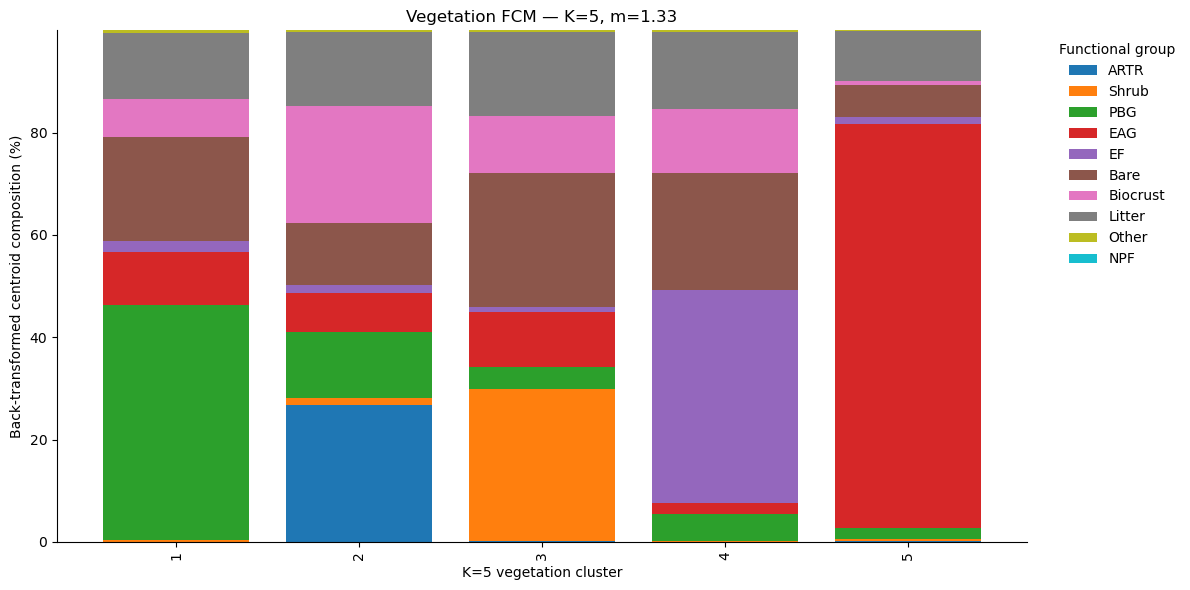

In [8]:
# =============================================================================
# 7. CENTROID COMPOSITION
# =============================================================================

plot_cols = [
    FG_LABELS[fg]
    for fg in FG_ALL
]

plot_df = (
    centroid_table
    .set_index("cluster_k5")[plot_cols]
)

ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    width=0.8,
)

ax.set_xlabel("K=5 vegetation cluster")
ax.set_ylabel("Back-transformed centroid composition (%)")
ax.set_title("Vegetation FCM — K=5, m=1.33")

ax.legend(
    title="Functional group",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    frameon=False,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 8. Output manifest

The key outputs are:

- `Derived/NCA_FCM_K5_m1p33_parent_assignments.csv`
- `Derived/NCA_FCM_K5_m1p33_model.npz`
- `Tables/K5_m1p33_parent_centroids_and_membership.csv`
- `Tables/K5_m1p33_FCM_metrics.csv`
- K8↔K5 crosswalk tables when the retained K=8 assignment file is present

The K=5 hard labels can then be used as the response in the supervised optical / optical+POLARIS comparison without changing the predictor architecture.

In [9]:
# =============================================================================
# 8. MANIFEST / QA
# =============================================================================

print("=" * 78)
print("K=5 VEGETATION FCM COMPLETE")
print("=" * 78)

print(f"\nRows clustered:       {len(veg_k5):,}")
print(f"Clusters:             {veg_k5['parent_cluster_k5'].nunique()}")
print(f"m:                    {M:.2f}")
print(f"Best seed:            {best_fit['seed']}")
print(f"Objective:            {best_fit['objective']:.6f}")
print(f"Restart ARI mean:     {restart_ari.mean():.4f}")
print(f"Reference rows u≥.60: {int(veg_k5['is_reference_k5'].sum()):,}")

print("\nDERIVED")
for p in sorted(DERIVED_DIR.glob("*")):
    print(" ", p)

print("\nTABLES")
for p in sorted(TABLE_DIR.glob("*")):
    print(" ", p)

K=5 VEGETATION FCM COMPLETE

Rows clustered:       1,171
Clusters:             5
m:                    1.33
Best seed:            50
Objective:            220.049659
Restart ARI mean:     0.8008
Reference rows u≥.60: 968

DERIVED
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33\Derived\NCA_FCM_K5_m1p33_model.npz
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33\Derived\NCA_FCM_K5_m1p33_parent_assignments.csv

TABLES
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33\Tables\K5_m1p33_FCM_metrics.csv
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33\Tables\K5_m1p33_parent_centroids_and_membership.csv
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33\Tables\K8_to_K5_crosswalk_counts.csv
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33\Tables\K8_to_K5_crosswalk_row_proportions.csv
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33\Tables\K8_to_K5_partition_similarity.csv
